# Unidad 1 - EDA

Vamos a hacer un análisis exploratorio de datos sobre todos los partidos de la selección Argentina entre 1901 y 2023.

### Paso 1: Importar datos.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("azminetoushikwasi/argentina-all-football-matches-19142023")

print("Path to dataset files:", path)

c:\Users\tetep\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\tetep\.cache\kagglehub\datasets\azminetoushikwasi\argentina-all-football-matches-19142023\versions\3


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
archivo = os.listdir(path)[0]
df=pd.read_csv(path+"/"+archivo)


### Paso 2: Exploración Inicial.

Veamos las dimensiones del dataset. 

In [3]:
df.shape

(1079, 6)

Veamos las primeras 10 filas del dataset.

In [4]:
df.head(10)

,Date,Match,Result,Score,Competition,Location
0,16 May 1901,Uruguay v Argentina,W,2-3,International Friendly,NaN
1,20 Jul 1902,Uruguay v Argentina,W,0-6,International Friendly,NaN
2,13 Sep 1903,Argentina v Uruguay,L,2-3,International Friendly,NaN
3,15 Aug 1905,Argentina v Uruguay,D,0-0,Copa Lipton,NaN
4,09 Jul 1906,Argentina v South Africa,L,0-1,International Friendly,NaN
5,15 Aug 1906,Uruguay v Argentina,W,0-2,Copa Lipton,NaN
6,21 Oct 1906,Argentina v Uruguay,W,2-1,Copa Newton,NaN
7,15 Aug 1907,Argentina v Uruguay,W,2-1,Copa Lipton,NaN
8,06 Oct 1907,Uruguay v Argentina,W,1-2,Copa Newton,NaN
9,09 Jul 1908,Brazil Rio XI v Argentina,W,2-3,XI v A,NaN


Información general del dataset.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         1079 non-null   str  
 1   Match        1079 non-null   str  
 2   Result       1079 non-null   str  
 3   Score        1078 non-null   str  
 4   Competition  1078 non-null   str  
 5   Location     2 non-null      str  
dtypes: str(6)
memory usage: 50.7 KB


Estadísticas descriptivas.

In [6]:
df.describe()

,Date,Match,Result,Score,Competition,Location
count,1079,1079,1079,1078,1078,2
unique,1069,132,4,72,61,1
top,15 Aug 1916,Argentina v Uruguay,W,1-0,International Friendly,Berlin
freq,2,102,603,120,330,2


### Paso 2: Calidad de datos.

Primero, veamos si hay datos faltantes. 

In [7]:
df.isnull().sum()

Date              0
Match             0
Result            0
Score             1
Competition       1
Location       1077
dtype: int64

Notamos que de los 1079 datos, nos falta el resultado de un partido, el torneo de otro y el lugar donde se jugaron 1077 partidos.

Observemos que la columna de Location no nos está aportando información. Por lo que vamos a elegir descartarla.

In [8]:
df.drop(columns=["Location"])

,Date,Match,Result,Score,Competition
0,16 May 1901,Uruguay v Argentina,W,2-3,International Friendly
1,20 Jul 1902,Uruguay v Argentina,W,0-6,International Friendly
2,13 Sep 1903,Argentina v Uruguay,L,2-3,International Friendly
3,15 Aug 1905,Argentina v Uruguay,D,0-0,Copa Lipton
4,09 Jul 1906,Argentina v South Africa,L,0-1,International Friendly
...,...,...,...,...,...
1074,30 Nov 2022,Poland v Argentina,W,0-2,FIFA World Cup
1075,03 Dec 2022,Argentina v Australia,W,2-1,FIFA World Cup
1076,09 Dec 2022,Netherlands v Argentina,W,2-2 (3-4),FIFA World Cup
1077,13 Dec 2022,Croatia v Argentina,W,0-3,FIFA World Cup


Veamos la fila donde falta el resultado.

In [9]:
df[df["Score"].isnull()]

,Date,Match,Result,Score,Competition,Location
1056,05 Sep 2021,Brazil v Argentina,FIFA World Cup,NaN,NaN,NaN


Resulta que el dato de resultado faltante coincide con el que falta la competición. 
Luego de investigar, encontramos que era un partido por las eliminatorias al mundial 2022 en el que entró un representante de ANVISA a los 5 minutos de haber comenzado el juego a detenerlo. Se terminó dictaminando el partido como nulo, es decir, ambas selecciones terminaron dichas eliminatorias con un partido menos. 

Como este partido no es un dato relevante al análisis, lo eliminamos.

In [10]:
df = df.dropna(subset=["Competition"])

In [11]:
df.shape

(1078, 6)

Ya sin datos faltantes, revisamos datos duplicados. 

In [12]:
duplicados=df.duplicated()
print(f"Total de filas duplicadas: {duplicados.sum()}   ")

Total de filas duplicadas: 0   


No necesitamos eliminar datos duplicados pues no hay.

Veamos primero si los partidos datan entre las fechas indicadas. Para eso, primero convertimos el formato de fecha.

In [13]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df["Year"] = df["Date"].dt.year
inconsistencias = df[
    (df["Year"] < 1901) |
    (df["Year"] > 2023)
]

print(inconsistencias)

Empty DataFrame
Columns: [Date, Match, Result, Score, Competition, Location, Year]
Index: []


### Paso 4: Análisis de datos. 

Queremos identificar los partidos en los que Argentina fue local o visitante. Notemos que en la columna "Match", los partidos vienen dados como "Equipo 1 v Equipo 2". Usamos la convención de que Equipo 1 es local. 

In [14]:
df["Localia"] = df["Match"].apply(
    lambda x: "Local" if x.split(" v ")[0] == "Argentina" else "Visitante"
)

df["Localia"].value_counts()

Localia
Local        589
Visitante    489
Name: count, dtype: int64

Notamos que Argentina jugó 100 partidos más como local que como visitante. 

Queremos ver como influye la localía en los resultados. Recordemos que W son los partidos ganados, L los perdidos y D los empatados. 

In [15]:
tabla = pd.crosstab(df["Localia"], df["Result"])

print(tabla)

Result       D    L    W
Localia                 
Local      117   63  409
Visitante  127  168  194


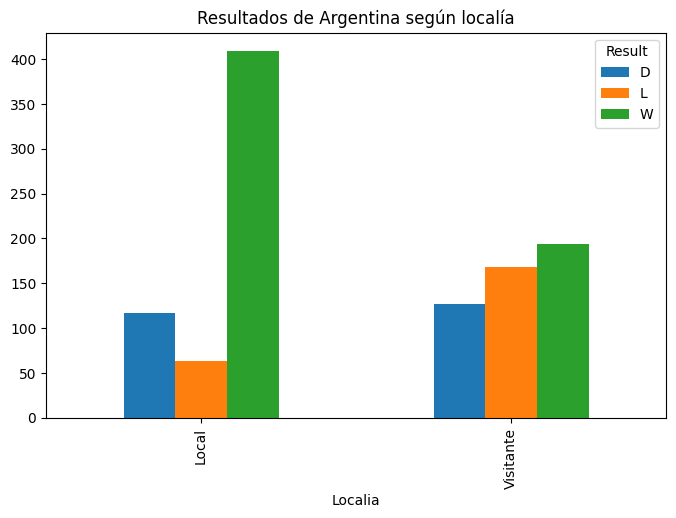

In [16]:
tabla.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Resultados de Argentina según localía")
plt.show()

In [17]:
tabla_pct = pd.crosstab(
    df["Localia"],
    df["Result"],
    normalize="index"
) * 100

print(tabla_pct)

Result             D          L          W
Localia                                   
Local      19.864177  10.696095  69.439728
Visitante  25.971370  34.355828  39.672802


Podemos ver que la selección suele ganar más cuando juega de local, y en los partidos de visitante le cuesta un poco más.

Ahora queremos ver en qué torneos le va mejor. 

In [18]:
#Nos quedamos con las 5 competiciones más jugadas por Argentina
top5_comp = df["Competition"].value_counts().head(5)
print(top5_comp)

Competition
International Friendly    330
FIFA World Cup            241
Copa America              202
Copa Lipton                31
Copa Newton                29
Name: count, dtype: int64


Dato de color: La Copa Lipton y la Copa Newton eran trofeos amistosos que se jugaban entre Argentina y Uruguay. 

In [19]:
df_top5 = df[df["Competition"].isin(top5_comp.index)]
df_top5["Competition"].value_counts()
pd.crosstab(df_top5["Competition"], df_top5["Result"])

Result,D,L,W
Competition,,,
Copa America,34,37,131
Copa Lipton,14,7,10
Copa Newton,6,8,15
FIFA World Cup,52,50,139
International Friendly,84,66,180


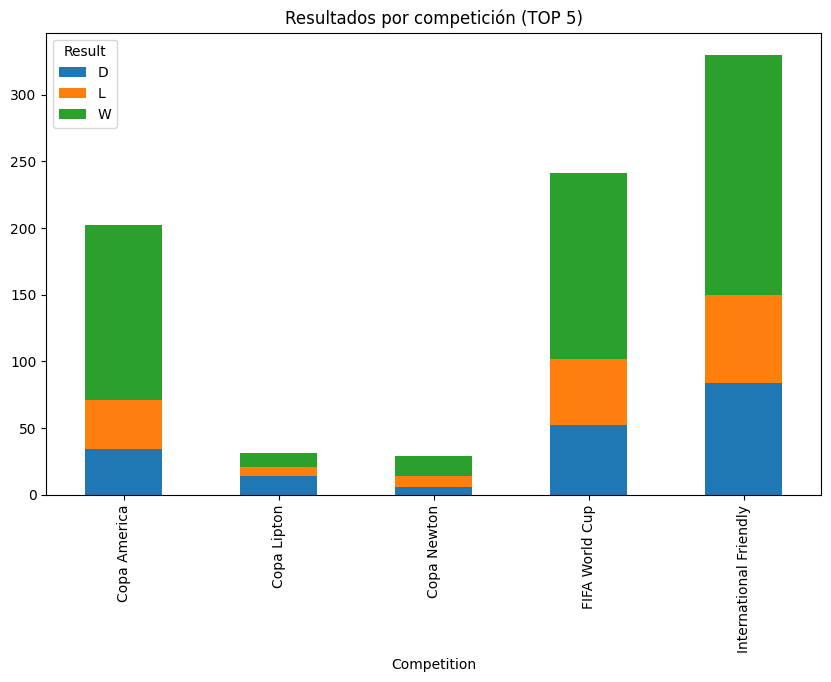

In [20]:
df_top5 = df[df["Competition"].isin(df["Competition"].value_counts().head(5).index)]

tabla = pd.crosstab(df_top5["Competition"], df_top5["Result"])

tabla.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Resultados por competición (TOP 5)")
plt.show()

In [21]:
tabla_pct = pd.crosstab(
    df_top5["Competition"],
    df_top5["Result"],
    normalize="index"
) * 100

print(tabla_pct.round(2))

Result                      D      L      W
Competition                                
Copa America            16.83  18.32  64.85
Copa Lipton             45.16  22.58  32.26
Copa Newton             20.69  27.59  51.72
FIFA World Cup          21.58  20.75  57.68
International Friendly  25.45  20.00  54.55


Notamos que nuestro mejor desempeño se da en la Copa América, de la cual somos los máximos ganadores del continente. 

Veamos ahora a los rivales a los que más nos enfrentamos.

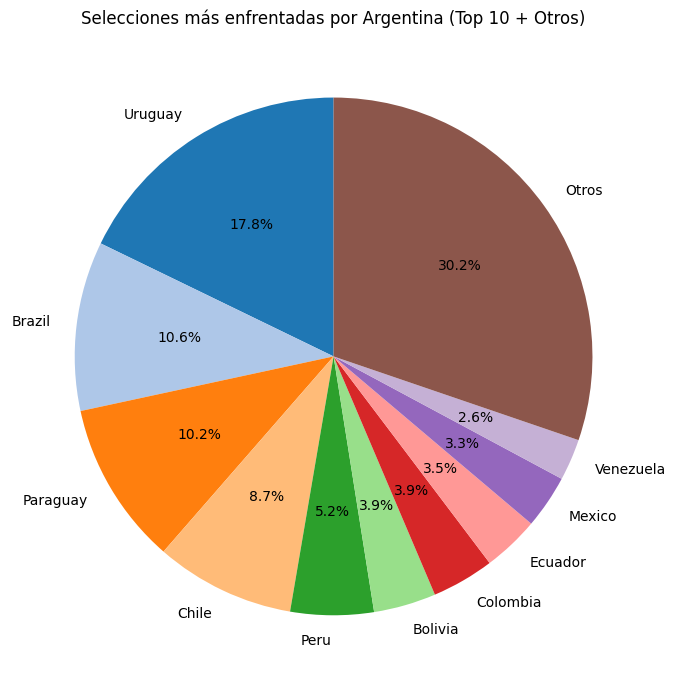

In [28]:
df["Rival"] = df["Match"].apply(
    lambda x:
    x.split(" v ")[1]
    if x.startswith("Argentina")
    else x.split(" v ")[0]
)
rivales = df["Rival"].value_counts()

top10 = rivales.head(10).copy()

otros = rivales.iloc[10:].sum()

top10["Otros"] = otros
plt.figure(figsize=(7,7))

plt.pie(
    top10.values,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
    colors=plt.cm.tab20.colors
)

plt.title("Selecciones más enfrentadas por Argentina (Top 10 + Otros)")
plt.tight_layout()
plt.show()

Miremos algo en los resultados. Queremos ver las goleadas a favor de nuestra selección. Consideramos como goleada a los partidos ganados con 3 o más goles de diferencia. 

In [30]:
#Separar goles
df[["GF", "GC"]] = df["Score"].str.extract(r"(\d+)\D+(\d+)")
df["GF"] = df["GF"].astype(int)
df["GC"] = df["GC"].astype(int)

#Ajustar los goles según la localía de Argentina
df["GF_arg"] = df.apply(
    lambda x: x["GF"] if x["Localia"] == "Local" else x["GC"],
    axis=1
)

df["GC_arg"] = df.apply(
    lambda x: x["GC"] if x["Localia"] == "Local" else x["GF"],
    axis=1
)


In [31]:
#Diferencia de goles
df["DifGol"] = df["GF_arg"] - df["GC_arg"]

#Goleadas
goleadas = df[df["DifGol"] >= 3]

print("Cantidad de goleadas a favor:", goleadas.shape[0])

Cantidad de goleadas a favor: 180


In [32]:
goleadas["Rival"] = goleadas["Match"].apply(
    lambda x: x.split(" v ")[1] if x.startswith("Argentina") else x.split(" v ")[0]
)

goleadas["Rival"].value_counts()

Rival
Uruguay                   23
Chile                     20
Paraguay                  20
Bolivia                   16
Venezuela                 16
Brazil                    11
Ecuador                   11
Peru                       7
Colombia                   7
Mexico                     4
USA                        4
Haiti                      3
Hungary                    3
Brazil Rio XI              2
Israel                     2
Japan                      2
Jamaica                    2
Guatemala                  2
CONCACAF                   1
Austria                    1
Switzerland                1
Ivory Coast                1
Greece                     1
Bulgaria                   1
Bosnia and Herzegovina     1
Qatar                      1
Serbia and Montenegro      1
Canada                     1
Korea Republic             1
Spain                      1
Albania                    1
Costa Rica                 1
Trinidad and Tobago        1
Hong Kong                  1
Panama  

<Axes: xlabel='Rival'>

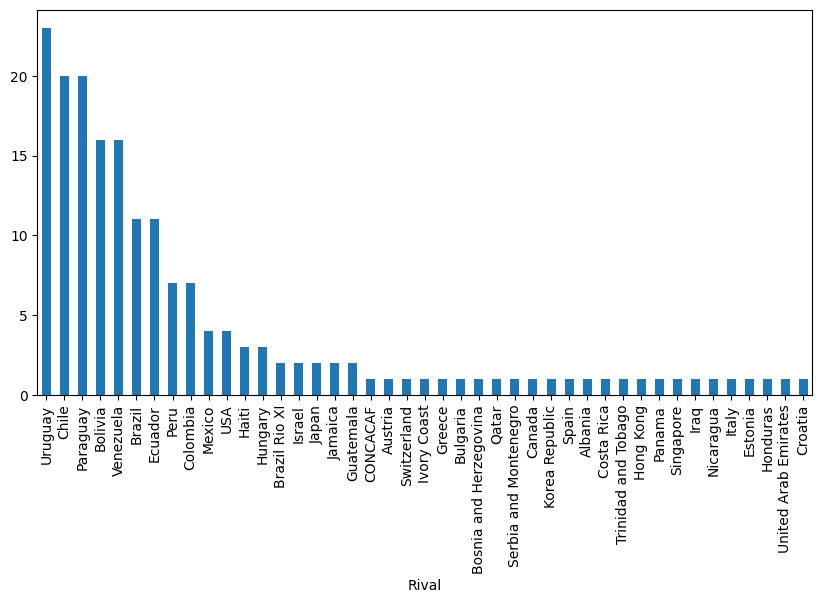

In [33]:
goleadas["Rival"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

Veamos que porcentaje de partidos fueron goleadas a favor nuestro, para cada rival.

In [39]:
df["DifGol"] = df["GF_arg"] - df["GC_arg"]

df["Goleada"] = df["DifGol"] >= 3
porcentaje = (
    df.groupby("Rival")["Goleada"]
    .mean()
    * 100
)

Nos quedamos con los rivales con los que jugamos más de 5 veces, para evitar casos en los que jugamos una única vez y goleamos, cuyo porcentaje sería 100%.

In [41]:
partidos = df["Rival"].value_counts()

porcentaje = porcentaje[
    partidos >= 5
]

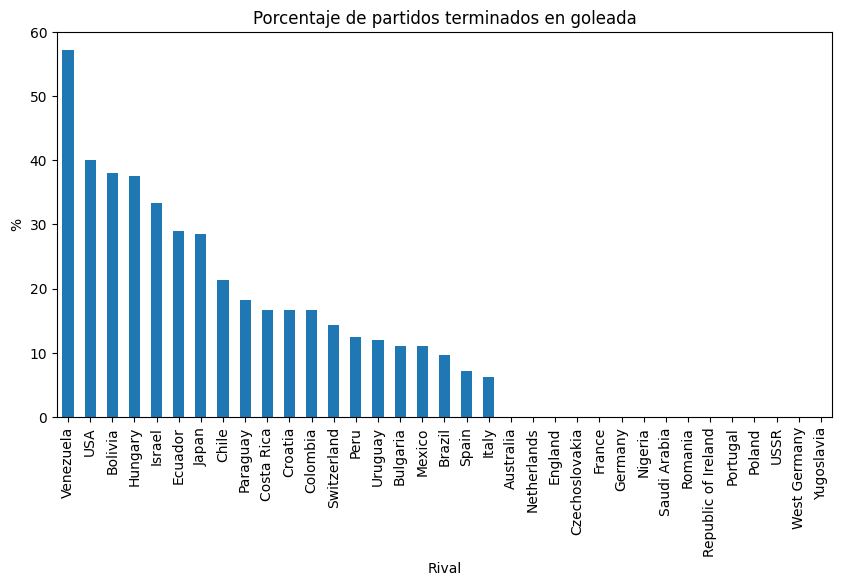

In [43]:
top = porcentaje.sort_values(
    ascending=False
)

top.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Porcentaje de partidos terminados en goleada"
)

plt.ylabel("%")

plt.show()

Ahora, hacemos una comparación entre el promedio de goles a favor y en contra por año.

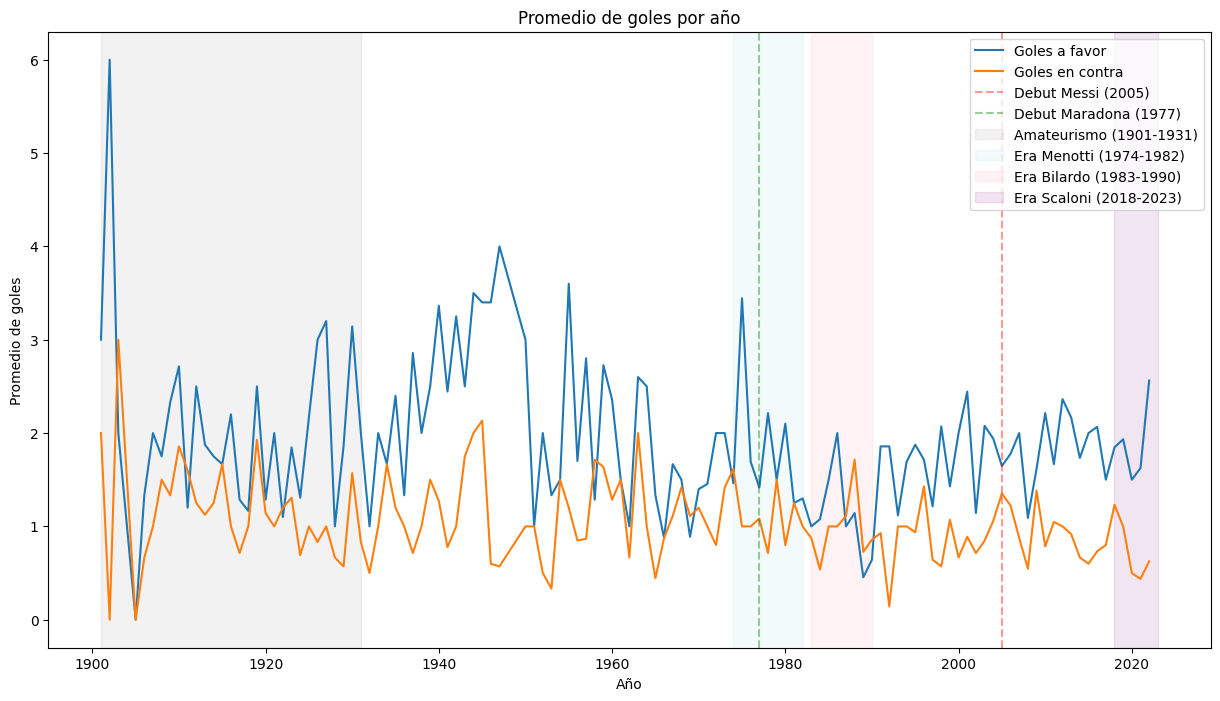

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Goles
df[["GF", "GC"]] = df["Score"].str.extract(r"(\d+)\D+(\d+)")
df["GF"] = df["GF"].astype(int)
df["GC"] = df["GC"].astype(int)

# Goles de Argentina según localía
df["GF_arg"] = df.apply(
    lambda x: x["GF"] if x["Localia"] == "Local" else x["GC"],
    axis=1
)

df["GC_arg"] = df.apply(
    lambda x: x["GC"] if x["Localia"] == "Local" else x["GF"],
    axis=1
)

# Fecha y año
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df["Year"] = df["Date"].dt.year

yearly = df.groupby("Year")[["GF_arg", "GC_arg"]].mean()


plt.figure(figsize=(15,8))

plt.plot(yearly.index, yearly["GF_arg"], label="Goles a favor")
plt.plot(yearly.index, yearly["GC_arg"], label="Goles en contra")
plt.axvline(x=2005, linestyle="--", color="red", label="Debut Messi (2005)", alpha=0.4)
plt.axvline(x=1977, linestyle="--", color="green", label="Debut Maradona (1977)", alpha=0.4)
plt.axvspan(1901, 1931, alpha=0.1, color="gray", label="Amateurismo (1901-1931)")
plt.axvspan(1974, 1982, alpha=0.1, color="skyblue", label="Era Menotti (1974-1982)")
plt.axvspan(1983, 1990, alpha=0.2, color="pink", label="Era Bilardo (1983-1990)")
plt.axvspan(2018, 2023, alpha=0.1, color="purple", label="Era Scaloni (2018-2023)")


plt.title("Promedio de goles por año")
plt.xlabel("Año")
plt.ylabel("Promedio de goles")
plt.legend()
plt.legend(loc="upper right")
plt.show()

Marcamos en el gráfico algunas fechas importantes. Queriamos si había etapas más bien defensivas o más bien ofensivas. 

# Conclusiones.

Notamos que la Selección Argentina es una selección bastante ganadora, con una amplia mejoría jugando de local.

Que, a lo largo de su historia, casi siempre hizo muchos más goles de los que recibió.

Que, en general, juega mejor en partidos importantes como lo son la Copa América o el Mundial, que en amistosos.

_Preguntas que pueden surgir:_
- ¿Existe relación entre cantidad de partidos jugados contra un rival y porcentaje de victorias?
- ¿Por qué se dieron las variaciones entre los promedios de goles?
- ¿Las mejoras observadas en el rendimiento parecen estar relacionadas con eventos importantes en la historia de la selección?